# ScpTensor 快速上手（DIA-NN 真实数据）

运行主线：
1. 一行读取 DIA-NN 结果文件
2. QC 与过滤
3. 预处理 + 填充
4. 降维 + 聚类
5. 验证新 I/O 的简化调用

目标是优先保证“能读、好读、少手工传参”。

## 0. 导入核心 API

这份教程优先使用顶层导出，便于记忆和复制。

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from scptensor import (
    calculate_feature_qc_metrics,
    calculate_sample_qc_metrics,
    cluster_kmeans,
    filter_features_by_missingness,
    filter_low_quality_samples,
    impute_knn,
    load_diann,
    log_transform,
    norm_median,
    reduce_pca,
    reduce_umap,
)
from scptensor.io import load_quant_table
from scptensor.viz import (
    plot_data_overview,
    plot_embedding_panels,
    plot_missingness_reduction,
    plot_preprocessing_summary,
    plot_qc_filtering_summary,
    plot_recent_operations,
    plot_reduction_summary,
)

## 1. 一行读取 DIA-NN 报告并构建 `ScpContainer`

这里直接使用仓库内置的 DIA-NN 报告（`data/dia/diann/...`）。

重点验证两点：
- 能否正确读入 DIA-NN 结果文件
- 能否减少手工传列名/手工构建矩阵的场景

Project root: /home/shenshang/projects/ScpTensor
DIA-NN file:  data/dia/diann/PXD054343/1_SC_LF_report.tsv
Container shape: 24 samples x 2719 proteins
Missing rate (raw): 26.01%


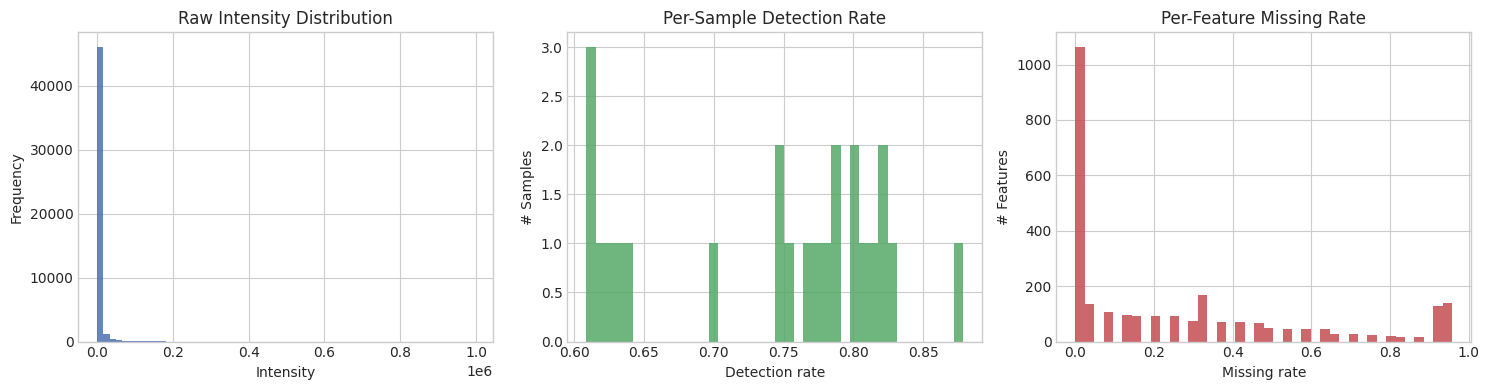

Peptide assay keys: ['peptides']
Peptide shape: 24 samples x 9279 precursors


_index
str
"""Olive_20231117_MGE_HStdia_S1_L…"
"""Olive_20231117_MGE_HStdia_S1_L…"
"""Olive_20231117_MGE_HStdia_S1_L…"
"""Olive_20231117_MGE_HStdia_S1_L…"
"""Olive_20231117_MGE_HStdia_S1_L…"


In [2]:
def locate_project_root(start: Path | None = None) -> Path:
    here = (start or Path.cwd()).resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "data" / "dia" / "diann").exists():
            return candidate
    raise FileNotFoundError("Cannot locate project root containing data/dia/diann")


def pick_diann_report(root: Path) -> Path:
    # 优先选较小且结构典型的 long report，保证教程运行稳定
    preferred = root / "data" / "dia" / "diann" / "PXD054343" / "1_SC_LF_report.tsv"
    if preferred.exists():
        return preferred

    candidates = sorted((root / "data" / "dia" / "diann").rglob("*report.tsv"))
    if not candidates:
        raise FileNotFoundError("No DIA-NN report TSV found under data/dia/diann")
    return candidates[0]


ROOT = locate_project_root()
DIANN_REPORT = pick_diann_report(ROOT)

# 最简调用：只传路径，软件/格式/主定量列都自动识别
container = load_diann(DIANN_REPORT)
raw_x = container.assays["proteins"].layers["raw"].X

print(f"Project root: {ROOT}")
print(f"DIA-NN file:  {DIANN_REPORT.relative_to(ROOT)}")
print(
    f"Container shape: {container.n_samples} samples x {container.assays['proteins'].n_features} proteins"
)
print(f"Missing rate (raw): {np.isnan(raw_x).mean():.2%}")

# 可视化：原始强度分布 + 每样本检出率 + 缺失率分布
plot_data_overview(container, assay_name="proteins", layer="raw", groupby="cell_cycle")
plt.show()

# 同一 DIA-NN 文件也可直接读肽段层级，且无需手动指定 assay_name
peptide_container = load_diann(DIANN_REPORT, level="peptide")
print(f"Peptide assay keys: {list(peptide_container.assays.keys())}")
print(
    f"Peptide shape: {peptide_container.n_samples} samples x {peptide_container.assays['peptides'].n_features} precursors"
)

container.obs.head()

## 2. QC 与过滤（最常用）

Samples: 24 -> 24
Features: 2719 -> 2346


_index,n_features_proteins,total_intensity_proteins
str,i64,f64
"""Olive_20231117_MGE_HStdia_S1_L…",1700,6.5134e6
"""Olive_20231117_MGE_HStdia_S1_L…",1657,5.3660e6
"""Olive_20231117_MGE_HStdia_S1_L…",1907,6.0834e6
"""Olive_20231117_MGE_HStdia_S1_L…",1679,6.2436e6
"""Olive_20231117_MGE_HStdia_S1_L…",1666,6.4509e6


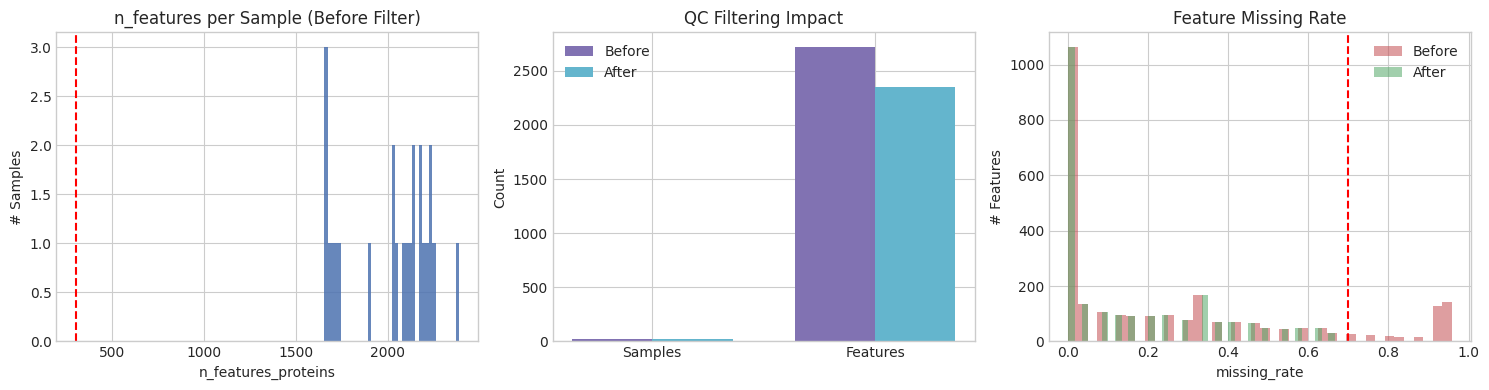

In [3]:
container = calculate_sample_qc_metrics(container, assay_name="proteins", layer_name="raw")
container = calculate_feature_qc_metrics(container, assay_name="proteins", layer_name="raw")

container_before_qc = container.copy()
before_samples = container_before_qc.n_samples
before_features = container_before_qc.assays["proteins"].n_features

container = filter_low_quality_samples(
    container,
    assay_name="proteins",
    min_features=300,
    nmads=3.0,
    use_mad=True,
)
container = filter_features_by_missingness(
    container,
    assay_name="proteins",
    layer_name="raw",
    max_missing_rate=0.70,
)

after_samples = container.n_samples
after_features = container.assays["proteins"].n_features

print(f"Samples: {before_samples} -> {after_samples}")
print(f"Features: {before_features} -> {after_features}")

plot_qc_filtering_summary(
    container_before_qc,
    container,
    assay_name="proteins",
    layer="raw",
    min_features=300,
    max_missing_rate=0.70,
)

preview_cols = [
    col
    for col in ["_index", "cell_cycle", "n_features_proteins", "total_intensity_proteins"]
    if col in container.obs.columns
]
container.obs.select(preview_cols).head()

## 3. 预处理与填充

Missing rate before impute: 15.92%
Missing rate after  impute: 0.00%


<Axes: title={'center': 'Missingness Reduction'}, ylabel='Missing rate'>

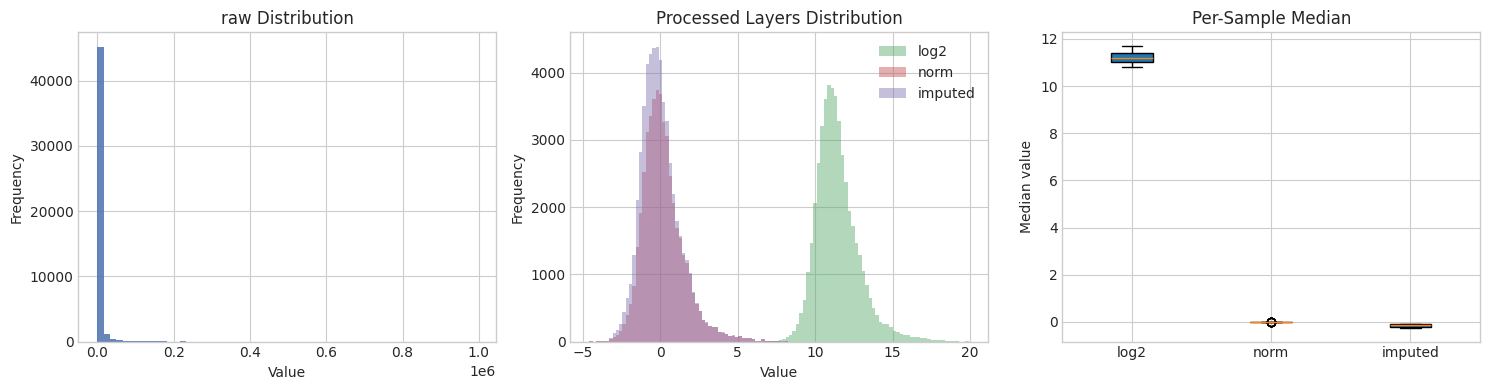

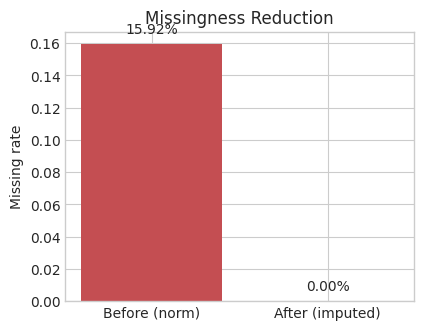

In [4]:
container = log_transform(
    container,
    assay_name="proteins",
    source_layer="raw",
    new_layer_name="log2",
    base=2.0,
)
container = norm_median(
    container,
    assay_name="proteins",
    source_layer="log2",
    new_layer_name="norm",
)

before_impute = np.isnan(container.assays["proteins"].layers["norm"].X).mean()

container = impute_knn(
    container,
    assay_name="proteins",
    source_layer="norm",
    new_layer_name="imputed",
    k=5,
)

after_impute = np.isnan(container.assays["proteins"].layers["imputed"].X).mean()

print(f"Missing rate before impute: {before_impute:.2%}")
print(f"Missing rate after  impute: {after_impute:.2%}")

plot_preprocessing_summary(
    container,
    assay_name="proteins",
    raw_layer="raw",
    transformed_layers=("log2", "norm", "imputed"),
)
plot_missingness_reduction(
    container,
    assay_name="proteins",
    before_layer="norm",
    after_layer="imputed",
)

## 4. 降维与聚类

/home/shenshang/projects/ScpTensor/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/shenshang/projects/ScpTensor/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


shape: (4, 2)
┌────────────────┬───────┐
│ kmeans_cluster ┆ count │
│ ---            ┆ ---   │
│ str            ┆ u32   │
╞════════════════╪═══════╡
│ 3              ┆ 4     │
│ 1              ┆ 4     │
│ 2              ┆ 8     │
│ 0              ┆ 8     │
└────────────────┴───────┘


array([<Axes: title={'center': 'PCA Cumulative Explained Variance'}, xlabel='# Components', ylabel='Cumulative ratio'>,
       <Axes: title={'center': 'Cluster Size Distribution'}, xlabel='kmeans_cluster', ylabel='# Samples'>],
      dtype=object)

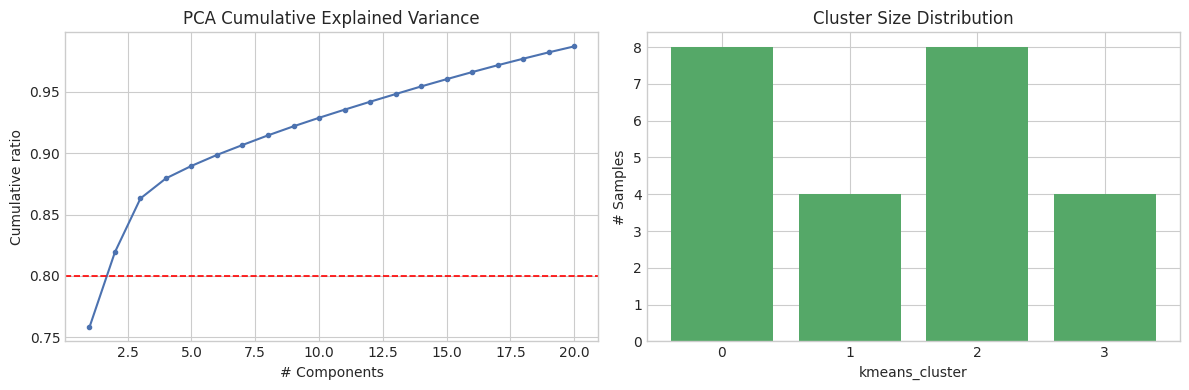

In [5]:
container = reduce_pca(
    container,
    assay_name="proteins",
    base_layer="imputed",
    n_components=20,
)

has_umap = True
try:
    container = reduce_umap(
        container,
        assay_name="pca",
        base_layer="X",
        n_neighbors=15,
        min_dist=0.2,
    )
except ModuleNotFoundError:
    has_umap = False
    print("UMAP 未安装，跳过 UMAP；仍可继续使用 PCA 结果。")

container = cluster_kmeans(
    container,
    assay_name="pca",
    base_layer="X",
    n_clusters=4,
    key_added="kmeans_cluster",
)

print(container.obs["kmeans_cluster"].value_counts())
plot_reduction_summary(container, pca_assay_name="pca", cluster_col="kmeans_cluster")

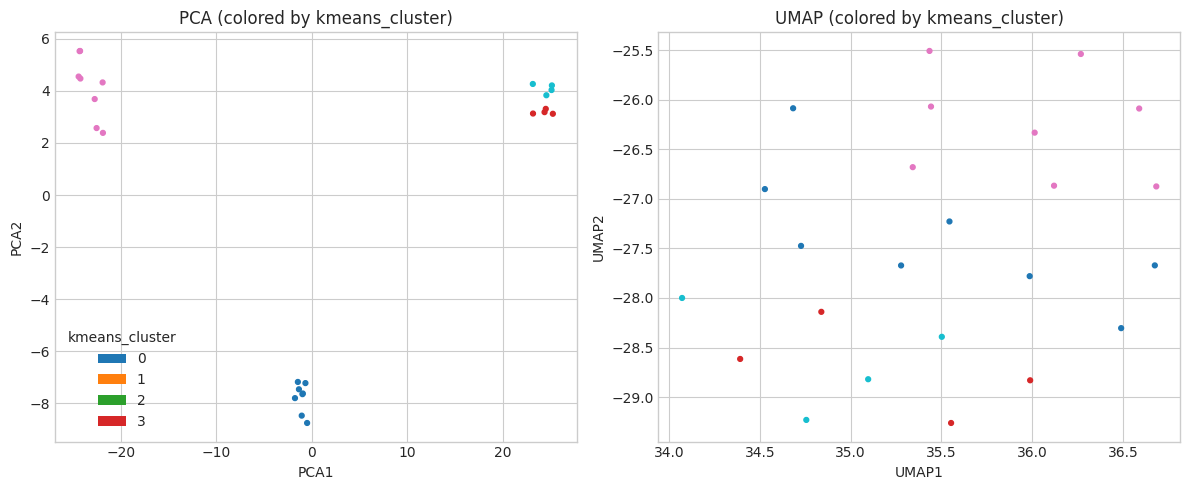

In [6]:
if has_umap:
    plot_embedding_panels(
        container,
        assay_names=("pca", "umap"),
        layer="X",
        color_by="kmeans_cluster",
        figsize=(12, 5),
    )
else:
    plot_embedding_panels(
        container,
        assay_names=("pca",),
        layer="X",
        color_by="kmeans_cluster",
        figsize=(6, 5),
    )

## 5. 新 I/O 端口简化调用验证

目标：减少手工传入列名、手工转矩阵、手工识别软件。

下面演示 3 种最简调用：
1. `load_diann(path)`：蛋白级自动导入
2. `load_diann(path, level="peptide")`：肽段级自动导入
3. `load_quant_table(path)`：自动识别软件 + long/matrix

protein_one_liner assays: ['proteins']
peptide_one_liner assays: ['peptides']
auto_one_liner assays: ['proteins']


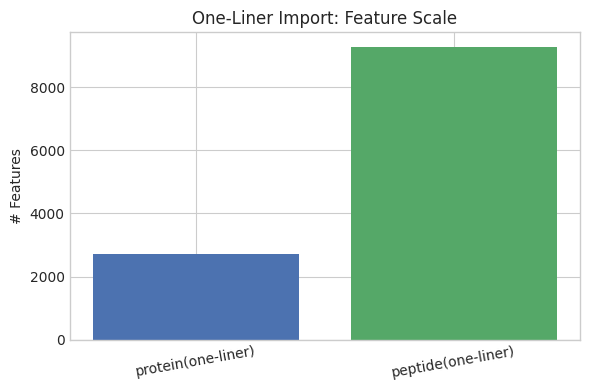

结论: 新 I/O 可直接读 DIA-NN，并显著减少手工传参。


In [7]:
protein_one_liner = load_diann(DIANN_REPORT)
peptide_one_liner = load_diann(DIANN_REPORT, level="peptide")
auto_one_liner = load_quant_table(DIANN_REPORT)

print("protein_one_liner assays:", list(protein_one_liner.assays.keys()))
print("peptide_one_liner assays:", list(peptide_one_liner.assays.keys()))
print("auto_one_liner assays:", list(auto_one_liner.assays.keys()))

assert "proteins" in protein_one_liner.assays
assert "peptides" in peptide_one_liner.assays
assert protein_one_liner.n_samples == auto_one_liner.n_samples

labels = ["protein(one-liner)", "peptide(one-liner)"]
values = [
    protein_one_liner.assays["proteins"].n_features,
    peptide_one_liner.assays["peptides"].n_features,
]

plt.figure(figsize=(6, 4))
plt.bar(labels, values, color=["#4C72B0", "#55A868"])
plt.ylabel("# Features")
plt.title("One-Liner Import: Feature Scale")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

print("结论: 新 I/O 可直接读 DIA-NN，并显著减少手工传参。")

Recent operations:
- load_quant_table
- calculate_feature_qc_metrics
- filter_samples
- filter_low_quality_samples
- filter_features
- filter_features_by_missingness
- log_transform
- normalization_median_centering
- impute_knn
- reduce_pca
- reduce_umap
- cluster_kmeans


<Axes: title={'center': 'Recent Operation Frequency'}, xlabel='Count'>

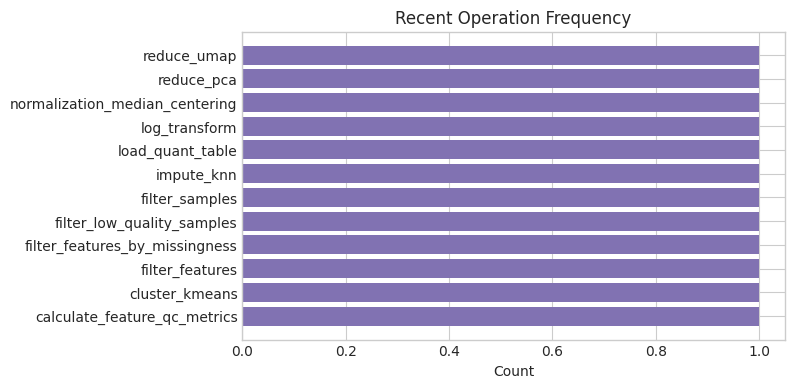

In [8]:
print("Recent operations:")
for log in container.history[-12:]:
    print(f"- {log.action}")

plot_recent_operations(container, n_recent=12)

## 小结

本教程验证了两件关键事情：

1. **能正确读入 DIA-NN 结果文件**
   - `load_diann(path)` 可直接把报告表导入为 `ScpContainer`
   - 支持同文件切换到肽段层级：`load_diann(path, level="peptide")`

2. **调用方式已简化，减少手工输入**
   - 默认自动识别软件、格式和主定量列
   - 常见场景可做到“一行导入”，无需手工拆矩阵、拼 `obs/var`

推荐记忆最短路径：
`load_diann -> QC/filter -> log_transform -> norm_median -> impute_knn -> reduce_pca/reduce_umap -> cluster_kmeans`